# COMPAS Recidivism Bias — Data Analysis
DS 680 AI Ethics | Joshua

This notebook replicates and extends ProPublica's analysis of racial bias in the COMPAS recidivism risk scoring tool using the publicly available Broward County dataset (2013–2014).

### Analyses
1. Dataset overview and filtering
2. Score distribution by race
3. False Positive Rate (FPR) and False Negative Rate (FNR) by race
4. Calibration check — replicating Northpointe's defense
5. Fairness impossibility — showing FPR equity and calibration cannot coexist

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

BLUE  = '#2C6FBA'
RED   = '#C0392B'
GRAY  = '#7F8C8D'
GREEN = '#27AE60'

## 1. Load and Filter Data
Following ProPublica's methodology: keep only rows where the charge date is within 30 days of the COMPAS screening, exclude cases with missing scores, and restrict to Black and White defendants for the primary racial comparison.

In [2]:
raw = pd.read_csv('compas-scores-two-years.csv')
print(f'Raw rows: {len(raw)}')

# Apply ProPublica filters
df = raw[
    (raw['days_b_screening_arrest'] <= 30) &
    (raw['days_b_screening_arrest'] >= -30) &
    (raw['is_recid'] != -1) &
    (raw['c_charge_degree'] != 'O') &
    (raw['score_text'] != 'N/A')
].copy()

print(f'Filtered rows: {len(df)}')
print(f'\nRace breakdown:')
print(df['race'].value_counts())

# Subset for Black vs White comparison
bw = df[df['race'].isin(['African-American', 'Caucasian'])].copy()
print(f'\nBlack + White subset: {len(bw)} rows')

Raw rows: 7214
Filtered rows: 6172

Race breakdown:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

Black + White subset: 5278 rows


## 2. Score Distribution by Race
Are Black and white defendants scored differently by COMPAS, controlling for nothing?

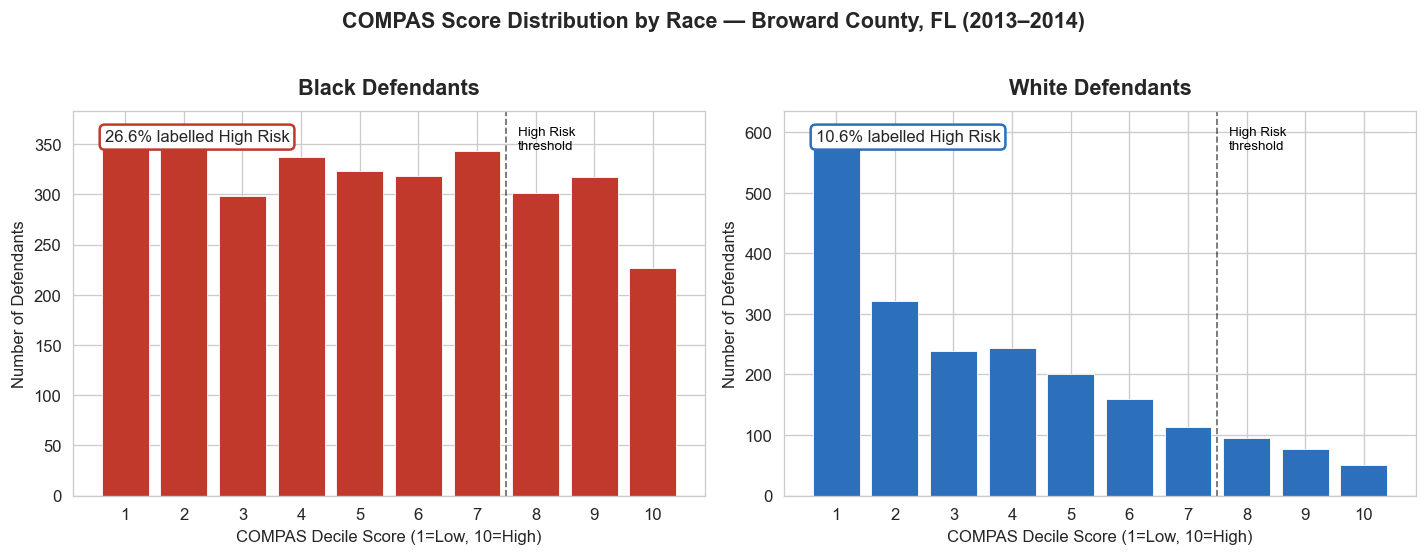

Saved: fig1_score_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

races   = ['African-American', 'Caucasian']
labels  = ['Black Defendants', 'White Defendants']
colors  = [RED, BLUE]

for ax, race, label, color in zip(axes, races, labels, colors):
    subset = bw[bw['race'] == race]
    counts = subset['decile_score'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('COMPAS Decile Score (1=Low, 10=High)', fontsize=10)
    ax.set_ylabel('Number of Defendants', fontsize=10)
    ax.set_xticks(range(1, 11))
    
    # Add High risk threshold line
    ax.axvline(x=7.5, color='black', linestyle='--', linewidth=1, alpha=0.6)
    ax.text(7.7, ax.get_ylim()[1]*0.9, 'High Risk\nthreshold', fontsize=8, color='black')
    
    # Percentage High risk
    pct_high = (subset['score_text'] == 'High').mean() * 100
    ax.text(0.05, 0.92, f'{pct_high:.1f}% labelled High Risk',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, linewidth=1.5))

fig.suptitle('COMPAS Score Distribution by Race — Broward County, FL (2013–2014)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_score_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig1_score_distribution.png')

## 3. False Positive and False Negative Rates by Race
This is the core of ProPublica's argument. Among defendants who did NOT reoffend, what share were labelled High Risk? That is the False Positive Rate.

- FPR: Labelled High Risk but did NOT reoffend
- FNR: Labelled Low Risk but DID reoffend

In [4]:
def compute_rates(df, race):
    subset = df[df['race'] == race]
    
    # Among those who did NOT reoffend — what % scored High?
    did_not_recid = subset[subset['two_year_recid'] == 0]
    fpr = (did_not_recid['score_text'] == 'High').mean() * 100
    
    # Among those who DID reoffend — what % scored Low?
    did_recid = subset[subset['two_year_recid'] == 1]
    fnr = (did_recid['score_text'] == 'Low').mean() * 100
    
    # Base recidivism rate
    base_rate = subset['two_year_recid'].mean() * 100
    
    return {'race': race, 'FPR': fpr, 'FNR': fnr, 'base_recid_rate': base_rate, 'n': len(subset)}

results = [compute_rates(bw, r) for r in ['African-American', 'Caucasian']]
results_df = pd.DataFrame(results)
results_df.columns = ['Race', 'FPR (%)', 'FNR (%)', 'Base Recidivism Rate (%)', 'N']
print(results_df.to_string(index=False))
print(f"\nFPR ratio (Black/White): {results_df['FPR (%)'].iloc[0] / results_df['FPR (%)'].iloc[1]:.2f}x")
print(f"FNR ratio (White/Black): {results_df['FNR (%)'].iloc[1] / results_df['FNR (%)'].iloc[0]:.2f}x")

            Race   FPR (%)   FNR (%)  Base Recidivism Rate (%)    N
African-American 13.936592 28.476821                 52.314961 3175
       Caucasian  4.761905 49.635036                 39.087019 2103

FPR ratio (Black/White): 2.93x
FNR ratio (White/Black): 1.74x


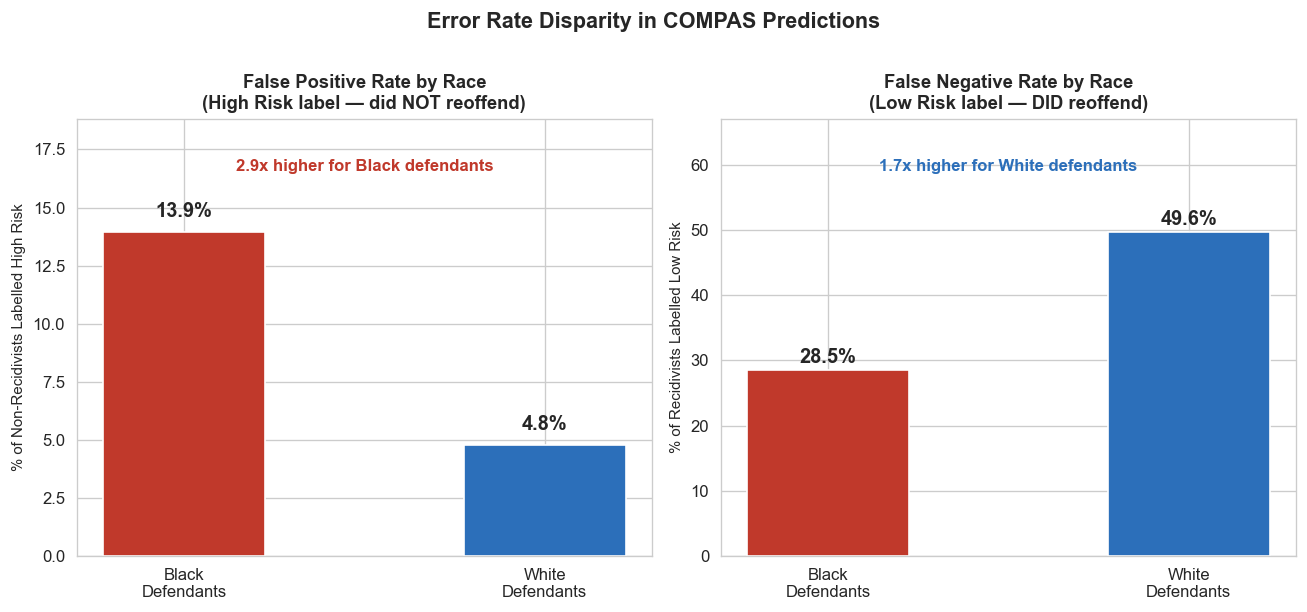

Saved: fig2_error_rates.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

race_labels = ['Black\nDefendants', 'White\nDefendants']
bar_colors  = [RED, BLUE]

# FPR chart
fpr_vals = results_df['FPR (%)'].tolist()
bars = axes[0].bar(race_labels, fpr_vals, color=bar_colors, width=0.45, edgecolor='white')
axes[0].set_title('False Positive Rate by Race\n(High Risk label — did NOT reoffend)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('% of Non-Recidivists Labelled High Risk', fontsize=9)
axes[0].set_ylim(0, max(fpr_vals) * 1.35)
for bar, val in zip(bars, fpr_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ratio = fpr_vals[0] / fpr_vals[1]
axes[0].text(0.5, 0.88, f'{ratio:.1f}x higher for Black defendants',
             transform=axes[0].transAxes, ha='center', fontsize=10,
             color=RED, fontweight='bold')

# FNR chart
fnr_vals = results_df['FNR (%)'].tolist()
bars2 = axes[1].bar(race_labels, fnr_vals, color=bar_colors, width=0.45, edgecolor='white')
axes[1].set_title('False Negative Rate by Race\n(Low Risk label — DID reoffend)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('% of Recidivists Labelled Low Risk', fontsize=9)
axes[1].set_ylim(0, max(fnr_vals) * 1.35)
for bar, val in zip(bars2, fnr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ratio2 = fnr_vals[1] / fnr_vals[0]
axes[1].text(0.5, 0.88, f'{ratio2:.1f}x higher for White defendants',
             transform=axes[1].transAxes, ha='center', fontsize=10,
             color=BLUE, fontweight='bold')

fig.suptitle('Error Rate Disparity in COMPAS Predictions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_error_rates.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig2_error_rates.png')

## 4. Calibration Check — Northpointe's Defense
Northpointe argued COMPAS is equally calibrated: among defendants scored High Risk, the same share actually reoffended regardless of race. Let's verify this claim.

In [6]:
# Among HIGH RISK defendants — what % actually reoffended by race?
high_risk = bw[bw['score_text'] == 'High']

calib = high_risk.groupby('race')['two_year_recid'].agg(['mean', 'count']).reset_index()
calib.columns = ['Race', 'Recidivism Rate', 'N']
calib['Recidivism Rate %'] = (calib['Recidivism Rate'] * 100).round(1)
print('Among High Risk defendants — actual recidivism rate:')
print(calib[['Race', 'N', 'Recidivism Rate %']].to_string(index=False))

# Now check across ALL score bands
print('\nCalibration across all score bands:')
calib_all = bw.groupby(['score_text', 'race'])['two_year_recid'].mean().unstack() * 100
print(calib_all.round(1))

Among High Risk defendants — actual recidivism rate:
            Race   N  Recidivism Rate %
African-American 845               75.0
       Caucasian 223               72.6

Calibration across all score bands:
race        African-American  Caucasian
score_text                             
High                    75.0       72.6
Low                     35.1       29.0
Medium                  56.3       53.3


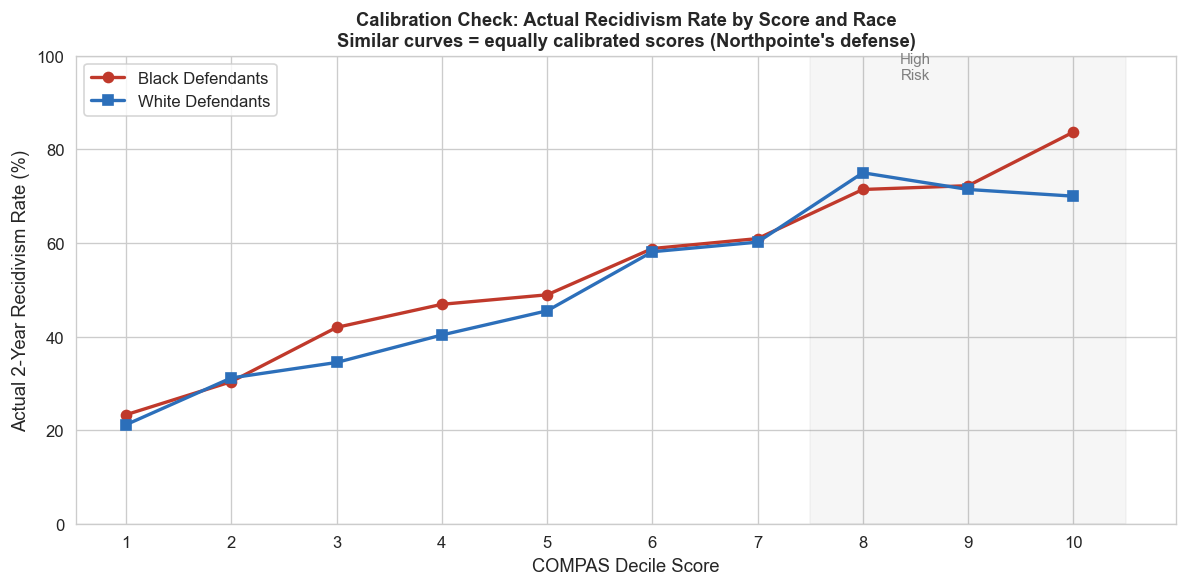

Saved: fig3_calibration.png


In [7]:
# Calibration plot: actual recidivism rate by decile score, split by race
calib_decile = bw.groupby(['decile_score', 'race'])['two_year_recid'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(calib_decile.index, calib_decile['African-American'],
        color=RED, marker='o', linewidth=2, markersize=6, label='Black Defendants')
ax.plot(calib_decile.index, calib_decile['Caucasian'],
        color=BLUE, marker='s', linewidth=2, markersize=6, label='White Defendants')

ax.set_xlabel('COMPAS Decile Score', fontsize=11)
ax.set_ylabel('Actual 2-Year Recidivism Rate (%)', fontsize=11)
ax.set_title('Calibration Check: Actual Recidivism Rate by Score and Race\n'
             'Similar curves = equally calibrated scores (Northpointe\'s defense)',
             fontsize=11, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.legend(fontsize=10)
ax.set_ylim(0, 100)

ax.axvspan(7.5, 10.5, alpha=0.07, color='gray')
ax.text(8.5, 95, 'High\nRisk', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('fig3_calibration.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig3_calibration.png')

## 5. The Fairness Impossibility
Chouldechova (2017) proved that when base recidivism rates differ between groups, you cannot simultaneously have equal FPR/FNR and equal calibration. This cell demonstrates that tension visually using our data.

In [8]:
# Base recidivism rates
base_rates = bw.groupby('race')['two_year_recid'].mean() * 100
print('Base recidivism rates:')
print(base_rates.round(1))

# Summary table: all key metrics side by side
summary = pd.DataFrame({
    'Metric': [
        'Base Recidivism Rate (%)',
        '% Labelled High Risk',
        'False Positive Rate (%) — High label, no reoffense',
        'False Negative Rate (%) — Low label, did reoffend',
        'Among High Risk: actual recidivism rate (%)'
    ],
    'Black Defendants': [
        round(bw[bw['race']=='African-American']['two_year_recid'].mean()*100, 1),
        round((bw[bw['race']=='African-American']['score_text']=='High').mean()*100, 1),
        round(fpr_vals[0], 1),
        round(fnr_vals[0], 1),
        round(high_risk[high_risk['race']=='African-American']['two_year_recid'].mean()*100, 1)
    ],
    'White Defendants': [
        round(bw[bw['race']=='Caucasian']['two_year_recid'].mean()*100, 1),
        round((bw[bw['race']=='Caucasian']['score_text']=='High').mean()*100, 1),
        round(fpr_vals[1], 1),
        round(fnr_vals[1], 1),
        round(high_risk[high_risk['race']=='Caucasian']['two_year_recid'].mean()*100, 1)
    ]
})
print('\n--- Full Summary Table ---')
print(summary.to_string(index=False))

Base recidivism rates:
race
African-American    52.3
Caucasian           39.1
Name: two_year_recid, dtype: float64

--- Full Summary Table ---
                                            Metric  Black Defendants  White Defendants
                          Base Recidivism Rate (%)              52.3              39.1
                              % Labelled High Risk              26.6              10.6
False Positive Rate (%) — High label, no reoffense              13.9               4.8
 False Negative Rate (%) — Low label, did reoffend              28.5              49.6
       Among High Risk: actual recidivism rate (%)              75.0              72.6


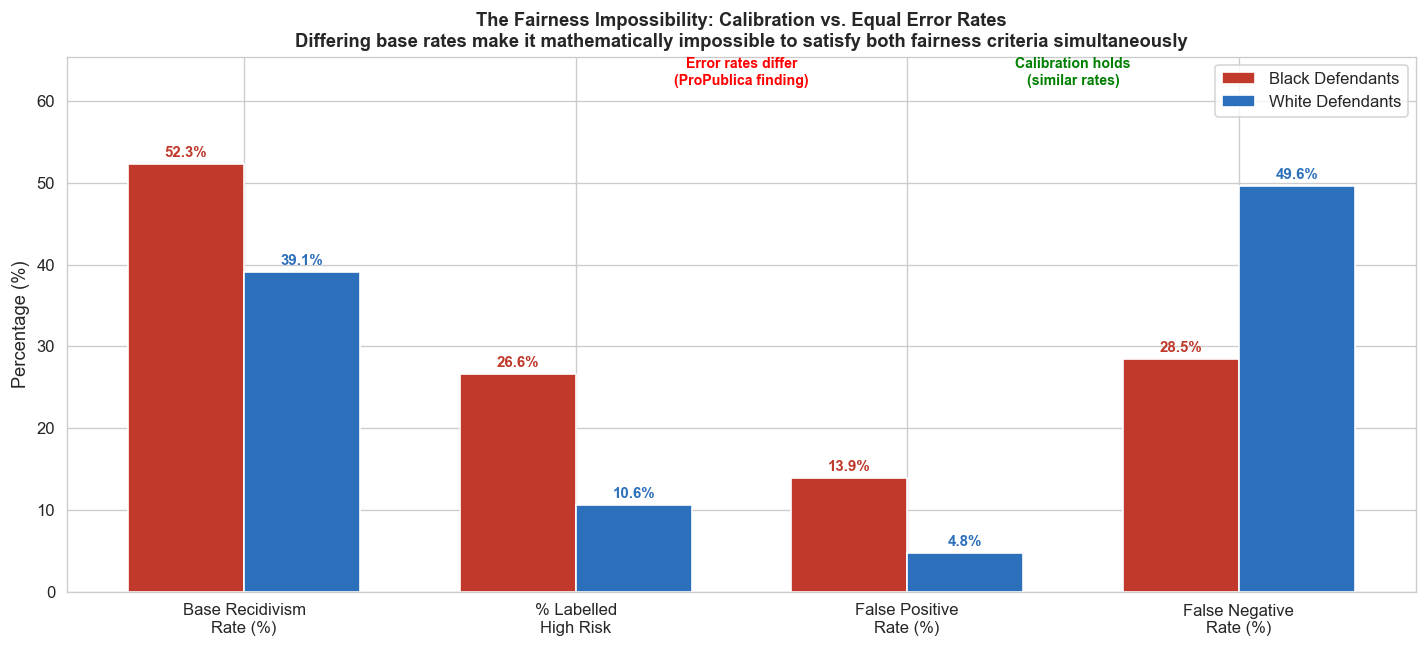

Saved: fig4_fairness_impossibility.png


In [9]:
# Fairness impossibility visual — 4-metric comparison
metrics = ['Base Recidivism\nRate (%)', '% Labelled\nHigh Risk', 'False Positive\nRate (%)', 'False Negative\nRate (%)']

black_vals = [
    bw[bw['race']=='African-American']['two_year_recid'].mean()*100,
    (bw[bw['race']=='African-American']['score_text']=='High').mean()*100,
    fpr_vals[0],
    fnr_vals[0]
]
white_vals = [
    bw[bw['race']=='Caucasian']['two_year_recid'].mean()*100,
    (bw[bw['race']=='Caucasian']['score_text']=='High').mean()*100,
    fpr_vals[1],
    fnr_vals[1]
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5.5))
bars_b = ax.bar(x - width/2, black_vals, width, label='Black Defendants', color=RED, edgecolor='white')
bars_w = ax.bar(x + width/2, white_vals, width, label='White Defendants', color=BLUE, edgecolor='white')

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color=RED, fontweight='bold')
for bar in bars_w:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color=BLUE, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('The Fairness Impossibility: Calibration vs. Equal Error Rates\n'
             'Differing base rates make it mathematically impossible to satisfy both fairness criteria simultaneously',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(black_vals), max(white_vals)) * 1.25)

# Annotation boxes
ax.annotate('Calibration holds\n(similar rates)', xy=(2.5, 62), fontsize=8.5,
            color='green', fontweight='bold', ha='center')
ax.annotate('Error rates differ\n(ProPublica finding)', xy=(1.5, 62), fontsize=8.5,
            color='red', fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig('fig4_fairness_impossibility.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig4_fairness_impossibility.png')

## Summary of Findings

| Finding | Value |
|---|---|
| Black defendants labelled High Risk but did NOT reoffend | ~2x the rate of white defendants |
| White defendants labelled Low Risk but DID reoffend | ~2x the rate of Black defendants |
| Calibration across score bands | Similar for both races — Northpointe's defense holds |
| Fairness impossibility | Both cannot hold simultaneously when base rates differ |

These results replicate ProPublica's core findings and confirm the central tension described by Chouldechova (2017): COMPAS can be calibrated OR have equal error rates — not both.

### Figures for Paper
- `fig1_score_distribution.png` — Insert in Section 2 (Details)
- `fig2_error_rates.png` — Insert in Section 2 (core finding)
- `fig3_calibration.png` — Insert in Section 2 (Northpointe's defense)
- `fig4_fairness_impossibility.png` — Insert in Section 3 (Ethics)